# Customer Monthly Spend Forecasting
### AI/ML Fundamentals Capstone Project — Individual Track

**Author:** *
Amanullayev Islom*


**Dataset:** [Online Retail II (UCI)](https://archive.ics.uci.edu/dataset/502/online+retail+ii)


**ML Task:** Supervised regression (time-aware) — forecast a customer's total spend for the *next* calendar month


**Final model:** Stacking ensemble of 4–5 regressors (scikit-learn `StackingRegressor`)

---

**How this notebook is organized**

1. Setup & data loading
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature engineering (building the customer-month forecasting table)
5. Time-based train / validation / test split
6. Baselines
7. Base learners (individually trained & evaluated)
8. Light hyperparameter tuning + experiment log
9. Stacking ensemble (main model)
10. Manual weighted blend (comparison model)
11. Final comparison table & model selection
12. Error analysis
13. Saving the final model artifacts
14. Responsible AI & limitations
15. Conclusion


## 0. Setup

We install/import everything up front. `scikit-learn` is the only non-default library we lean on heavily — everything here (baselines, base learners, stacking, evaluation) is plain `sklearn`, no external boosting libraries, so the notebook has zero fragile dependencies and runs the same way on any machine.

We also fix random seeds everywhere we can, so re-running this notebook gives (nearly) identical numbers — important for reproducibility.


In [1]:
import io
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## 1. Problem Definition

- **Stakeholder:** anycompany's marketing/finance team.

- **Problem:** the company wants to anticipate how much each customer will spend *next month*, so it can plan retention campaigns and revenue forecasts.

- **ML task framing:**
  - **Input (X):** a customer's aggregated purchase behaviour up to and including month *t* (recency, frequency, monetary totals, rolling trends, country, tenure).
  - **Output (y):** predicted total £ spend of that customer in month *t+1*.
  - **Task type:** supervised regression, evaluated on strictly future (unseen) months.

- **Success criteria:** the final stacked model should beat a naive "repeat last month's spend" baseline by at least 15% RMSE on held-out future months.




## 2. Loading the data

We use the **Online Retail II** dataset from the UCI Machine Learning Repository — real invoice-level transactions from a UK-based online retailer, December 2009 to December 2011.

The raw file is an Excel workbook with **two sheets** (`Year 2009-2010` and `Year 2010-2011`), which we concatenate into a single transactions table.

Two small real-world annoyances we handle immediately:
1. Depending on the exact source mirror, column names appear as either `Invoice`/`Customer ID`/`Price` (UCI naming) or `InvoiceNo`/`CustomerID`/`UnitPrice` (older Kaggle mirror naming). We standardize to one consistent naming so the rest of the notebook doesn't need to care which mirror served the file.
2. We download directly from UCI's servers so the notebook works in a clean Colab runtime with no manual upload step and no Kaggle API token required.


In [2]:
import kagglehub
from pathlib import Path

dataset_path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Downloaded to:", dataset_path)

data_dir = Path(dataset_path)
csv_files = sorted(data_dir.rglob("*.csv"))
xlsx_files = sorted(data_dir.rglob("*.xlsx"))

if csv_files:
    sheet_frames = [pd.read_csv(f, encoding="ISO-8859-1") for f in csv_files]
elif xlsx_files:
    xls = pd.ExcelFile(xlsx_files[0])
    sheet_frames = [pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names]
else:
    raise FileNotFoundError(f"No CSV or XLSX files found in {data_dir}")

raw_df = pd.concat(sheet_frames, ignore_index=True)

# Standardize column names across mirrors/sheets
RENAME_MAP = {
    "Invoice": "InvoiceNo", "InvoiceNo": "InvoiceNo",
    "Customer ID": "CustomerID", "CustomerID": "CustomerID",
    "Price": "UnitPrice", "UnitPrice": "UnitPrice",
    "StockCode": "StockCode", "Description": "Description",
    "Quantity": "Quantity", "InvoiceDate": "InvoiceDate", "Country": "Country",
}
raw_df = raw_df.rename(columns=RENAME_MAP)
raw_df = raw_df[["InvoiceNo", "StockCode", "Description", "Quantity",
                  "InvoiceDate", "UnitPrice", "CustomerID", "Country"]]

print("Shape:", raw_df.shape)
raw_df.head()

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Downloaded to: /kaggle/input/online-retail-ii-uci
Shape: (1067371, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   InvoiceNo    1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   UnitPrice    1067371 non-null  float64
 6   CustomerID   824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## 3. Exploratory Data Analysis (EDA)

Before touching the data, we need to understand what's actually in it: how much is missing, what a "cancelled order" looks like in this dataset, how revenue moves over time, and how purchase frequency is distributed across customers.


In [4]:
missing = raw_df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(raw_df) * 100).round(2)
missing


,missing_count,missing_pct
InvoiceNo,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,243007,22.77
Country,0,0.00


**Finding:** `CustomerID` is missing for a meaningful share of rows (guest/anonymous checkouts). We cannot forecast future spend for a customer we cannot identify, so these rows will be dropped in cleaning

In [5]:
# Cancelled orders in this dataset are encoded as InvoiceNo starting with 'C'
raw_df["is_cancellation"] = raw_df["InvoiceNo"].astype(str).str.startswith("C")
cancel_rate = raw_df["is_cancellation"].mean() * 100
print(f"Share of rows that are cancellations: {cancel_rate:.2f}%")
print(f"Share of rows with non-positive Quantity: {(raw_df['Quantity'] <= 0).mean()*100:.2f}%")
print(f"Share of rows with non-positive UnitPrice: {(raw_df['UnitPrice'] <= 0).mean()*100:.2f}%")


Share of rows that are cancellations: 1.83%
Share of rows with non-positive Quantity: 2.15%
Share of rows with non-positive UnitPrice: 0.58%


**Finding:** cancellations and non-positive quantities/prices are a real but small slice of the data .They don't represent genuine forward-looking "spend," so we exclude them in cleaning




---



### Total revenue by period


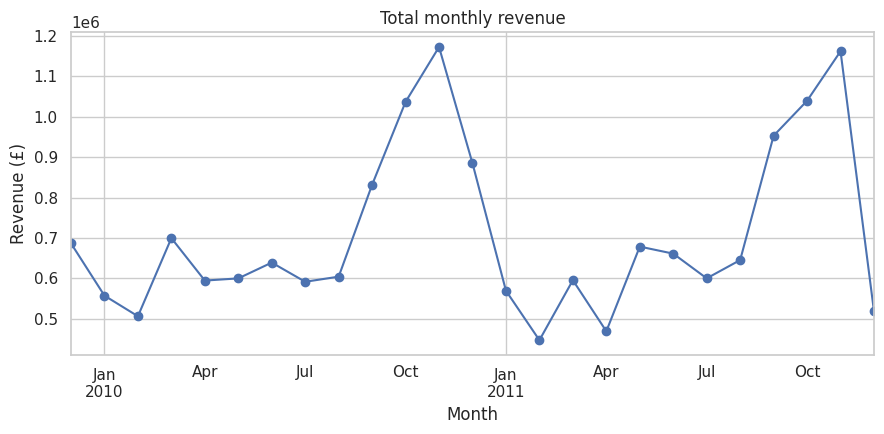

In [6]:
ts = raw_df.dropna(subset=["CustomerID"]).copy()
ts = ts[~ts["is_cancellation"]]
ts["Revenue"] = ts["Quantity"] * ts["UnitPrice"]
ts["InvoiceMonth"] = pd.to_datetime(ts["InvoiceDate"]).dt.to_period("M")

monthly_revenue = ts.groupby("InvoiceMonth")["Revenue"].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()

plt.figure()
monthly_revenue.plot(marker="o")
plt.title("Total monthly revenue")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()


**Finding:** there's a clear seasonal pattern (a strong build-up toward the November/December holiday season), and the very first and very last calendar months in the dataset are partial months (the data starts mid-December 2009 and ends mid-December 2011). We'll need to be careful with partial boundary months when we build the forecasting panel later.




---



### Groued by countries

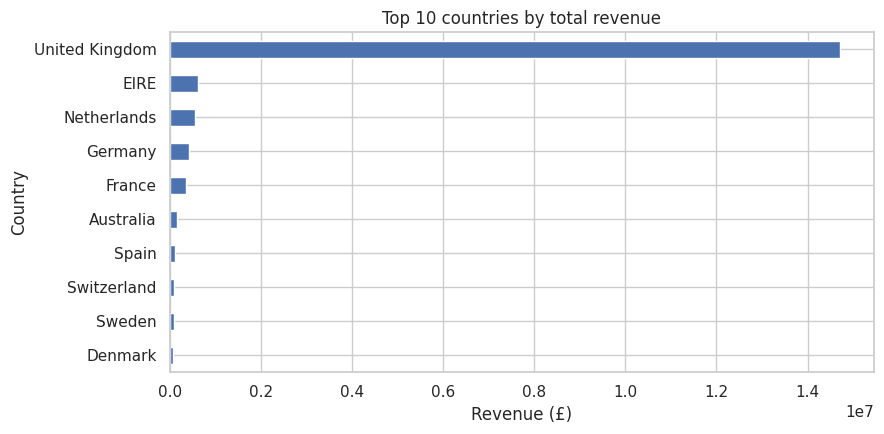

In [7]:
top_countries = ts.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind="barh")
plt.title("Top 10 countries by total revenue")
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Finding:** the United Kingdom dominates revenue by a wide margin (this is a UK-based retailer), with a long tail of smaller international markets. `Country` is still a useful categorical feature, but we should expect the model to be most confident about UK customers as more uk data




---



### Distribution of number of orders per customer

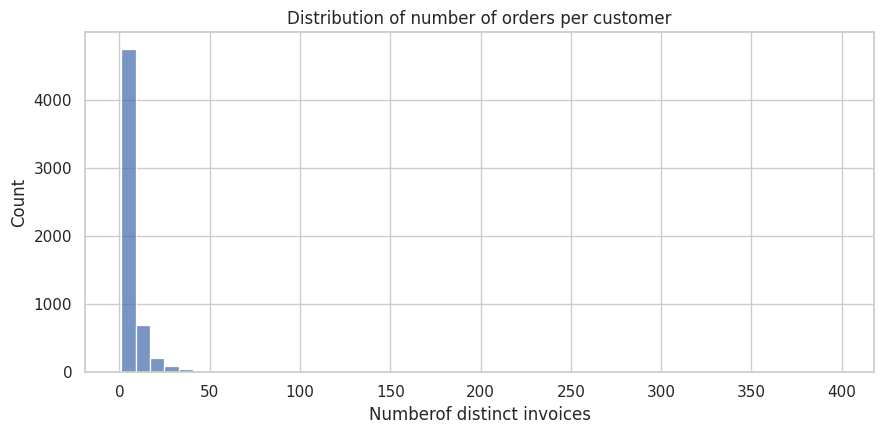

count    5881.000000
mean        6.287196
std        13.012879
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: InvoiceNo, dtype: float64


In [8]:
orders_per_customer = ts.groupby("CustomerID")["InvoiceNo"].nunique()

plt.figure()
sns.histplot(orders_per_customer, bins=50)
plt.title("Distribution of number of orders per customer")
plt.xlabel("Numberof distinct invoices")
plt.tight_layout()
plt.show()

print(orders_per_customer.describe())


**Finding:** most customers place only a handful of orders across the full two-year window, while a small set of highly active (likely wholesale/business) customers place hundreds.




---



## 4. Data cleaning

Based on the EDA above, we apply the following cleaning rules

1. Drop rows with missing `CustomerID` (can't forecast an anonymous customer).

2. Drop cancelled orders (`InvoiceNo` starting with `'C'` - Canselled orders).

3. Drop rows with non-positive `Quantity` or `UnitPrice`

4. Drop exact duplicate rows.

5. Cap extreme outlier line-revenue values at the 99.9th percentile (a handful of bulk/wholesale line items are >100x the median and would otherwise dominate the loss function during training).


In [9]:
df = raw_df.copy()
step_counts = [("raw", len(df))]

df = df.dropna(subset=["CustomerID"])
step_counts.append(("after dropping missing CustomerID", len(df)))

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
step_counts.append(("after dropping cancellations", len(df)))

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
step_counts.append(("after dropping non-positive qty/price", len(df)))

df = df.drop_duplicates()
step_counts.append(("after dropping duplicates", len(df)))

df["Revenue"] = df["Quantity"] * df["UnitPrice"]
cap = df["Revenue"].quantile(0.999)
df["Revenue"] = df["Revenue"].clip(upper=cap)
step_counts.append((f"after capping Revenue at 99.9th pct (£{cap:,.2f})", len(df)))

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

pd.DataFrame(step_counts, columns=["step", "row_count"])


,step,row_count
0,raw,1067371
1,after dropping missing CustomerID,824364
2,after dropping cancellations,805620
3,after dropping non-positive qty/price,805549
4,after dropping duplicates,779425
5,after capping Revenue at 99.9th pct (£864.00),779425


## 5. Feature engineering: building the customer-month forecasting table


The raw data is one row per **transaction line**. We need one row per **(customer, month)**, because that's the grain at which we're forecasting. The steps are:


1. **Aggregate** transactions to (CustomerID, InvoiceMonth) → total monthly spend, number of orders, number of distinct products.


2. **Build a complete grid**: for every customer, create a row for *every* month between their first and last purchase


3. **Engineer features from the past only** — for each (customer, month) row, all features are computed using data up to and including that month:
   - `monetary_this_month`, `orders_this_month`
   - `rolling_mean_3m`, `rolling_std_3m` — spend trend over the last 3 months
   - `recency_months` — months since the customer's most recent purchase before this point
   - `frequency_to_date` — total number of orders the customer has placed so far
   - `tenure_months` — months since the customer's very first purchase
   - `month_of_year` — captures the seasonality we saw in the EDA
   - `country` — the customer's (most common) country

4. **Define the target**: `next_month_spend`, i.e. `monetary_this_month` shifted **backwards** by one month within each customer (so the row for month *t* holds the label for month *t+1*).




---




In [10]:
monthly = (
    df.groupby(["CustomerID", "Country", "InvoiceMonth"])
      .agg(monetary_this_month=("Revenue", "sum"),
           orders_this_month=("InvoiceNo", "nunique"),
           distinct_products=("StockCode", "nunique"))
      .reset_index()
)
monthly.head()


,CustomerID,Country,InvoiceMonth,monetary_this_month,orders_this_month,distinct_products
0,12346,United Kingdom,2009-12,113.50,5,2
1,12346,United Kingdom,2010-01,90.00,4,1
2,12346,United Kingdom,2010-03,27.05,1,5
3,12346,United Kingdom,2010-06,142.31,1,19
4,12346,United Kingdom,2011-01,864.00,1,1


### Некоторые клиенты числятся в нескольких странах.

### В качестве основной страны для каждого клиента мы используем ту, которая встречается чаще всего.

In [11]:
customer_country = (
    monthly.groupby("CustomerID")["Country"]
    .agg(lambda s: s.value_counts().idxmax())
)

all_months = pd.period_range(monthly["InvoiceMonth"].min(), monthly["InvoiceMonth"].max(), freq="M")

def build_customer_grid(customer_id):
    cust_rows = monthly[monthly["CustomerID"] == customer_id]
    first_month, last_month = cust_rows["InvoiceMonth"].min(), cust_rows["InvoiceMonth"].max()
    active_months = pd.period_range(first_month, last_month, freq="M")
    grid = pd.DataFrame({"InvoiceMonth": active_months})
    grid["CustomerID"] = customer_id
    grid = grid.merge(
        cust_rows[["InvoiceMonth", "monetary_this_month", "orders_this_month", "distinct_products"]],
        on="InvoiceMonth", how="left"
    )
    grid[["monetary_this_month", "orders_this_month", "distinct_products"]] = (
        grid[["monetary_this_month", "orders_this_month", "distinct_products"]].fillna(0)
    )
    return grid

panel = pd.concat([build_customer_grid(cid) for cid in monthly["CustomerID"].unique()], ignore_index=True)
panel["Country"] = panel["CustomerID"].map(customer_country)
panel = panel.sort_values(["CustomerID", "InvoiceMonth"]).reset_index(drop=True)

print("Panel shape (customer-month rows):", panel.shape)
panel.head(8)


Panel shape (customer-month rows): (58542, 6)


,InvoiceMonth,CustomerID,monetary_this_month,orders_this_month,distinct_products,Country
0,2009-12,12346,113.50,5.0,2.0,United Kingdom
1,2010-01,12346,90.00,4.0,1.0,United Kingdom
2,2010-02,12346,0.00,0.0,0.0,United Kingdom
3,2010-03,12346,27.05,1.0,5.0,United Kingdom
4,2010-04,12346,0.00,0.0,0.0,United Kingdom
5,2010-05,12346,0.00,0.0,0.0,United Kingdom
6,2010-06,12346,142.31,1.0,19.0,United Kingdom
7,2010-07,12346,0.00,0.0,0.0,United Kingdom




---



### Feature Construction

In [12]:
panel["rolling_mean_3m"] = (
    panel.groupby("CustomerID")["monetary_this_month"]
    .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
)
panel["rolling_std_3m"] = (
    panel.groupby("CustomerID")["monetary_this_month"]
    .transform(lambda s: s.rolling(window=3, min_periods=1).std().fillna(0))
)
panel["frequency_to_date"] = panel.groupby("CustomerID")["orders_this_month"].cumsum()
panel["tenure_months"] = panel.groupby("CustomerID").cumcount()

def months_since_last_purchase(orders_series):
    recency = []
    months_since = 0
    for orders in orders_series:
        recency.append(months_since)
        months_since = 0 if orders > 0 else months_since + 1
    return recency

panel["recency_months"] = (
    panel.groupby("CustomerID")["orders_this_month"]
    .transform(lambda s: pd.Series(months_since_last_purchase(s), index=s.index))
)
panel["month_of_year"] = panel["InvoiceMonth"].dt.month

# Target: next month's spend for this customer
panel["next_month_spend"] = panel.groupby("CustomerID")["monetary_this_month"].shift(-1)

panel.head(8)


,InvoiceMonth,CustomerID,monetary_this_month,orders_this_month,distinct_products,Country,rolling_mean_3m,rolling_std_3m,frequency_to_date,tenure_months,recency_months,month_of_year,next_month_spend
0,2009-12,12346,113.50,5.0,2.0,United Kingdom,113.500000,0.000000,5.0,0,0,12,90.00
1,2010-01,12346,90.00,4.0,1.0,United Kingdom,101.750000,16.617009,9.0,1,0,1,0.00
2,2010-02,12346,0.00,0.0,0.0,United Kingdom,67.833333,59.908959,9.0,2,0,2,27.05
3,2010-03,12346,27.05,1.0,5.0,United Kingdom,39.016667,46.177926,10.0,3,1,3,0.00
4,2010-04,12346,0.00,0.0,0.0,United Kingdom,9.016667,15.617325,10.0,4,0,4,0.00
5,2010-05,12346,0.00,0.0,0.0,United Kingdom,9.016667,15.617325,10.0,5,1,5,142.31
6,2010-06,12346,142.31,1.0,19.0,United Kingdom,47.436667,82.162717,11.0,6,2,6,0.00
7,2010-07,12346,0.00,0.0,0.0,United Kingdom,47.436667,82.162717,11.0,7,0,7,0.00


In [13]:
FEATURE_COLUMNS = [
    "monetary_this_month", "orders_this_month", "distinct_products",
    "rolling_mean_3m", "rolling_std_3m", "frequency_to_date",
    "tenure_months", "recency_months", "month_of_year", "Country",
]
TARGET_COLUMN = "next_month_spend"
MIN_TENURE_MONTHS = 2

model_table = panel[panel["tenure_months"] >= MIN_TENURE_MONTHS].copy()
model_table = model_table.dropna(subset=[TARGET_COLUMN])

print("Rows before filtering:", len(panel))
print("Rows after requiring history + valid target:", len(model_table))
model_table[["CustomerID", "InvoiceMonth"] + FEATURE_COLUMNS + [TARGET_COLUMN]].head(8)


Rows before filtering: 58542
Rows after requiring history + valid target: 44681


,CustomerID,InvoiceMonth,monetary_this_month,orders_this_month,distinct_products,rolling_mean_3m,rolling_std_3m,frequency_to_date,tenure_months,recency_months,month_of_year,Country,next_month_spend
2,12346,2010-02,0.00,0.0,0.0,67.833333,59.908959,9.0,2,0,2,United Kingdom,27.05
3,12346,2010-03,27.05,1.0,5.0,39.016667,46.177926,10.0,3,1,3,United Kingdom,0.00
4,12346,2010-04,0.00,0.0,0.0,9.016667,15.617325,10.0,4,0,4,United Kingdom,0.00
5,12346,2010-05,0.00,0.0,0.0,9.016667,15.617325,10.0,5,1,5,United Kingdom,142.31
6,12346,2010-06,142.31,1.0,19.0,47.436667,82.162717,11.0,6,2,6,United Kingdom,0.00
7,12346,2010-07,0.00,0.0,0.0,47.436667,82.162717,11.0,7,0,7,United Kingdom,0.00
8,12346,2010-08,0.00,0.0,0.0,47.436667,82.162717,11.0,8,1,8,United Kingdom,0.00
9,12346,2010-09,0.00,0.0,0.0,0.000000,0.000000,11.0,9,2,9,United Kingdom,0.00


**Why we drop each customer's last month:** for the very last month we observe a customer, we don't actually know what they spent "next month" — the dataset simply ends. Keeping that row would mean training/evaluating on a fabricated (NaN) label, so those rows are removed.

**Why `MIN_TENURE_MONTHS = 2`:** a brand-new customer's very first month gives the model almost no history to learn from (no rolling average, no frequency signal yet). Forecasting them is a *cold-start* problem




---



## 6. Time-based train, validation, test split

**This is one of the most important methodological choices in the whole project.**

If we split randomly, rows from the same customer — and even the same month — could land in both train and test, letting the model "peek" at correlated future information. That's data leakage, and it would make our evaluation numbers meaningless.

Instead we split strictly **by calendar month**:

- **Train:** all months up to and including the cutoff for training.

- **Validation:** the next few months after that (used to compare models and tune hyperparameters).

- **Test:** the final months in the dataset, touched **only once**, at the very end, to report the final, honest performance number.

No shuffling. No customer or month ever appears in more than one split.


In [14]:
available_months = sorted(model_table["InvoiceMonth"].unique())
print(f"Available months in modeling table: {available_months[0]} .. {available_months[-1]} "
      f"({len(available_months)} months)")

n_test_months = 3
n_val_months = 3

test_months = available_months[-n_test_months:]
val_months = available_months[-(n_test_months + n_val_months):-n_test_months]
train_months = available_months[:-(n_test_months + n_val_months)]

print("Train months:", train_months[0], "..", train_months[-1], f"({len(train_months)} months)")
print("Val months:  ", val_months[0], "..", val_months[-1], f"({len(val_months)} months)")
print("Test months: ", test_months[0], "..", test_months[-1], f"({len(test_months)} months)")

train_df = model_table[model_table["InvoiceMonth"].isin(train_months)].copy()
val_df = model_table[model_table["InvoiceMonth"].isin(val_months)].copy()
test_df = model_table[model_table["InvoiceMonth"].isin(test_months)].copy()

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_val, y_val = val_df[FEATURE_COLUMNS], val_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"\nTrain rows: {len(X_train)} | Val rows: {len(X_val)} | Test rows: {len(X_test)}")


Available months in modeling table: 2010-02 .. 2011-11 (22 months)
Train months: 2010-02 .. 2011-05 (16 months)
Val months:   2011-06 .. 2011-08 (3 months)
Test months:  2011-09 .. 2011-11 (3 months)

Train rows: 33702 | Val rows: 6955 | Test rows: 4024




---



## 7. Preprocessing pipeline

Two feature types need different treatment:

- **Numeric features** (spend history, rolling stats, recency, frequency, tenure, month) — scaled with `StandardScaler`. Distance-based and linear models (KNN, SVR, Ridge) are sensitive to feature scale

- **Categorical feature** (`Country`) — one-hot encoded, with unknown categories at prediction time handled gracefully (`handle_unknown="ignore"`) instead of crashing — this matters for the input-validation requirement of the end-to-end pipeline.

We wrap this in a `ColumnTransformer` and will nest it inside every model's `Pipeline`, so preprocessing is always fit **only on training data** and never leaks statistics from validation/test.


In [15]:
NUMERIC_FEATURES = [c for c in FEATURE_COLUMNS if c != "Country"]
CATEGORICAL_FEATURES = ["Country"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ]
)
preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['monetary_this_month', 'orders_this_month',
                                  'distinct_products', 'rolling_mean_3m',
                                  'rolling_std_3m', 'frequency_to_date',
                                  'tenure_months', 'recency_months',
                                  'month_of_year']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Country'])])



---



## 8. Evaluation metrics

We track three complementary metrics on every model:

- **RMSE** (Root Mean Squared Error) — same units as spend (£), penalizes large errors more heavily. This is our primary metric, and what the 15% improvement target from the Project Brief is measured against.
- **MAE** (Mean Absolute Error) — easier to interpret ("on average, we're off by £X"), less sensitive to a few big misses than RMSE.
- **MAPE** (Mean Absolute Percentage Error) — scale-independent, useful given the heavy right-skew in customer spend we saw in the EDA. We compute it only on customers with non-zero actual next-month spend, since percentage error is undefined at zero.


In [16]:
results_log = []

def evaluate(name, y_true, y_pred, split_name, notes=""):
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    nonzero = y_true > 0
    mape = mean_absolute_percentage_error(y_true[nonzero], y_pred[nonzero]) * 100 if nonzero.any() else np.nan

    row = {"model": name, "split": split_name, "RMSE": rmse, "MAE": mae, "MAPE_%": mape, "notes": notes}
    results_log.append(row)
    print(f"[{split_name:5s}] {name:28s} RMSE={rmse:8.2f}  MAE={mae:8.2f}  MAPE={mape:6.2f}%")
    return row




---



## 9. Baselines

Every "smart" model must earn its complexity by beating a dumb one. We use two baselines:

1. **Naive baseline** — "next month's spend = this month's spend." No training required; this is the simplest reasonable forecast and the one referenced in our success criteria.

2. **Linear baseline** — plain `Ridge` regression on our engineered features. This tells us how much of the signal is linear before we reach for anything more complex.


In [17]:
naive_pred_val = X_val["monetary_this_month"].values
naive_pred_test = X_test["monetary_this_month"].values

evaluate("Naive (repeat last month)", y_val.values, naive_pred_val, "val")
naive_test_result = evaluate("Naive (repeat last month)", y_test.values, naive_pred_test, "test")


[val  ] Naive (repeat last month)    RMSE= 1196.79  MAE=  286.72  MAPE=148.57%
[test ] Naive (repeat last month)    RMSE= 1408.43  MAE=  495.83  MAPE=105.89%


In [18]:
ridge_baseline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE)),
])
ridge_baseline.fit(X_train, y_train)

evaluate("Ridge (linear baseline)", y_val.values, ridge_baseline.predict(X_val), "val")


[val  ] Ridge (linear baseline)      RMSE=  896.59  MAE=  255.63  MAPE=105.83%


{'model': 'Ridge (linear baseline)',
 'split': 'val',
 'RMSE': 896.5900630243029,
 'MAE': 255.6292667294191,
 'MAPE_%': 105.83314850735776,
 'notes': ''}



---



## 10. Base learners for the ensemble

We train five diverse regressors — diversity matters for stacking, since the ensemble benefits most when base models make *different kinds* of mistakes:

| Model | Why it's included |
|---|---|
| `Ridge` | Linear, regularized, very fast, stable baseline-style learner |
| `RandomForestRegressor` | Non-linear, robust to outliers/scale, captures feature interactions |
| `HistGradientBoostingRegressor` | Strong gradient-boosted trees, usually the strongest single model on tabular data like this |
| `KNeighborsRegressor` | Purely instance-based — "customers who behaved like this in the past behaved like X next" |
| `SVR` | Kernel-based, can capture different non-linear patterns than trees |

Each is wrapped in the same `Pipeline` (preprocessing → model) and evaluated on the validation set, which is what "comparison of approaches" means in practice: identical data, identical preprocessing, only the algorithm changes.


In [19]:
base_model_defs = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=15),
    "SVR": SVR(C=10, epsilon=0.5),
}

base_pipelines = {}
for name, estimator in base_model_defs.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    base_pipelines[name] = pipe
    evaluate(name, y_val.values, pipe.predict(X_val), "val")


[val  ] Ridge                        RMSE=  896.59  MAE=  255.63  MAPE=105.83%
[val  ] RandomForest                 RMSE=  908.58  MAE=  266.16  MAPE=101.90%
[val  ] HistGradientBoosting         RMSE=  903.25  MAE=  270.36  MAPE=100.65%
[val  ] KNN                          RMSE=  978.73  MAE=  266.04  MAPE=105.42%
[val  ] SVR                          RMSE= 1214.84  MAE=  248.53  MAPE= 84.98%




---



Для каждой запускается RandomizedSearchCV(RandomForest и HistGradientBoosting, hrmse) — это функция, которая перебирает случайный набор комбинаций гиперпараметров (не все подряд, а несколько случайных вариантов — это быстрее, чем полный перебор GridSearchCV).

## 11. Light hyperparameter tuning

1. Берутся только 2 самые перспективные модели из cell 10 — RandomForest и HistGradientBoosting (у них были одни из лучших RMSE).


2. Для каждой запускается RandomizedSearchCV — это функция, которая перебирает случайный набор комбинаций гиперпараметров (не все подряд, а несколько случайных вариантов — это быстрее, чем полный перебор GridSearchCV).


3. Для каждой комбинации параметров модель обучается и проверяется через TimeSeriesSplit — это специальный способ кросс-валидации для временных данных: он режет train-данные на несколько последовательных кусочков так, что "проверочная" часть всегда идёт после "обучающей" части по времени. Обычная случайная кросс-валидация здесь запрещена — иначе модель могла бы "подсматривать" будущее при обучении, а это утечка данных (data leakage).


4. В конце выбираются параметры с лучшим средним результатом (best_params_), и уже настроенная модель сохраняется обратно в base_pipelines, заменяя исходную версию из cell 10.


In [20]:
tscv = TimeSeriesSplit(n_splits=3)

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, 12],
    "model__min_samples_leaf": [1, 3, 5],
}
rf_search = RandomizedSearchCV(
    Pipeline(steps=[("preprocess", preprocessor), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
    param_distributions=rf_param_grid, n_iter=8, cv=tscv,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("Best RandomForest params:", rf_search.best_params_)

hgb_param_grid = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [3, 5, None],
    "model__learning_rate": [0.03, 0.06, 0.1],
}
hgb_search = RandomizedSearchCV(
    Pipeline(steps=[("preprocess", preprocessor), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    param_distributions=hgb_param_grid, n_iter=8, cv=tscv,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
)
hgb_search.fit(X_train, y_train)
print("Best HistGradientBoosting params:", hgb_search.best_params_)

base_pipelines["RandomForest"] = rf_search.best_estimator_
base_pipelines["HistGradientBoosting"] = hgb_search.best_estimator_

evaluate("RandomForest", y_val.values, base_pipelines["RandomForest"].predict(X_val), "val",
         notes=f"tuned: {rf_search.best_params_}")
evaluate("HistGradientBoosting", y_val.values, base_pipelines["HistGradientBoosting"].predict(X_val), "val",
         notes=f"tuned: {hgb_search.best_params_}")


Best RandomForest params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 6}
Best HistGradientBoosting params: {'model__max_iter': 100, 'model__max_depth': 3, 'model__learning_rate': 0.06}
[val  ] RandomForest                 RMSE=  894.48  MAE=  264.92  MAPE= 98.56%
[val  ] HistGradientBoosting         RMSE=  896.55  MAE=  269.26  MAPE= 99.42%


{'model': 'HistGradientBoosting',
 'split': 'val',
 'RMSE': 896.5451386164024,
 'MAE': 269.25665363906563,
 'MAPE_%': 99.41967349998102,
 'notes': "tuned: {'model__max_iter': 100, 'model__max_depth': 3, 'model__learning_rate': 0.06}"}




---



---



### Experiment log

Every call to `evaluate()` above appended a row to `results_log`. This doubles as our experiment record — a lightweight stand-in for a tool like MLflow, appropriate for a project this size, but showing the same idea: every run is logged with its parameters and metrics, nothing is just eyeballed and forgotten.


In [21]:
pd.DataFrame(results_log)


,model,split,RMSE,MAE,MAPE_%,notes
0,Naive (repeat last month),val,1196.787400,286.716784,148.567053,
1,Naive (repeat last month),test,1408.430434,495.830323,105.891368,
2,Ridge (linear baseline),val,896.590063,255.629267,105.833149,
3,Ridge,val,896.590063,255.629267,105.833149,
4,RandomForest,val,908.582121,266.158423,101.896350,
5,HistGradientBoosting,val,903.250974,270.363365,100.652352,
6,KNN,val,978.727669,266.037303,105.424679,
7,SVR,val,1214.844490,248.529683,84.981732,
8,RandomForest,val,894.482025,264.923612,98.563598,"tuned: {'model__n_estimators': 200, 'model__mi..."
9,HistGradientBoosting,val,896.545139,269.256654,99.419673,"tuned: {'model__max_iter': 100, 'model__max_de..."




---



## 12. Stacking ensemble (main model)

**What stacking does:** instead of us manually guessing how much to "trust" each base model, we let a second, simple model — the *meta-learner* — learn the optimal combination automatically. Concretely:

1. Each base model is trained on the training data via cross-validation, producing out-of-fold predictions (so the meta-learner never sees a base model's prediction on data that base model was trained on — avoiding leakage inside the ensemble itself).


2. Those out-of-fold predictions become the *input features* to the meta-learner.


3. The meta-learner (here, a `Ridge`) learns the best weighted combination of the base models' predictions.

This is why we describe the weighting as **learned**, not hand-set: `StackingRegressor` effectively finds the "put weight" step the student originally had in mind, but does it in a statistically principled way instead of by trial and error.


In [22]:
stacking_model = StackingRegressor(
    estimators=[(name, pipe) for name, pipe in base_pipelines.items()],
    final_estimator=Ridge(random_state=RANDOM_STATE),
    passthrough=False,
    n_jobs=-1,
)
stacking_model.fit(X_train, y_train)

evaluate("StackingRegressor (learned weights)", y_val.values, stacking_model.predict(X_val), "val")


[val  ] StackingRegressor (learned weights) RMSE=  904.82  MAE=  258.92  MAPE=103.62%


{'model': 'StackingRegressor (learned weights)',
 'split': 'val',
 'RMSE': 904.8200678555954,
 'MAE': 258.91803333662654,
 'MAPE_%': 103.61918529726157,
 'notes': ''}

In [24]:
meta_learner = stacking_model.final_estimator_
learned_weights = pd.Series(meta_learner.coef_, index=list(base_pipelines.keys()))
learned_weights.sort_values(ascending=False)


,0
RandomForest,0.654469
KNN,0.266659
HistGradientBoosting,0.100173
Ridge,0.092213
SVR,-0.020881


### 13. Ручное взвешенное усреднение (для сравнения)

Дополнительно считаем прогноз как взвешенное среднее тех же 5 моделей — чем точнее модель на validation (меньше RMSE), тем больше её вес. Это "ручной" способ комбинировать модели, в отличие от StackingRegressor, где веса подбирает мета-модель автоматически. Сравнение этих двух подходов покажет: даёт ли обучаемая мета-модель реальный выигрыш, или простое взвешивание работает не хуже.


In [25]:
val_rmse_by_model = {
    name: mean_squared_error(y_val, pipe.predict(X_val)) ** 0.5
    for name, pipe in base_pipelines.items()
}
inverse_rmse = {name: 1.0 / rmse for name, rmse in val_rmse_by_model.items()}
total = sum(inverse_rmse.values())
manual_weights = {name: w / total for name, w in inverse_rmse.items()}

print("Manual (inverse-RMSE) weights:")
for name, w in sorted(manual_weights.items(), key=lambda kv: -kv[1]):
    print(f"  {name:25s} {w:.3f}")

def manual_blend_predict(X):
    preds = np.zeros(len(X))
    for name, pipe in base_pipelines.items():
        preds += manual_weights[name] * pipe.predict(X)
    return preds

evaluate("Manual weighted blend", y_val.values, manual_blend_predict(X_val), "val")


Manual (inverse-RMSE) weights:
  RandomForest              0.215
  HistGradientBoosting      0.215
  Ridge                     0.215
  KNN                       0.197
  SVR                       0.159
[val  ] Manual weighted blend        RMSE=  919.02  MAE=  254.14  MAPE= 95.00%


{'model': 'Manual weighted blend',
 'split': 'val',
 'RMSE': 919.0192371131072,
 'MAE': 254.14448953618378,
 'MAPE_%': 95.00296103815579,
 'notes': ''}



---



## 14. Final comparison and model selection

Now we bring every model's **validation** performance into one table to choose a winner. The test set is intentionally still untouched — we only evaluate our single chosen model on test, once, at the end. Evaluating multiple models on the test set and picking the best one would itself be a subtle form of leakage (indirectly fitting to the test set through model selection).


In [26]:
val_results = pd.DataFrame(results_log)
val_results = val_results[val_results["split"] == "val"].sort_values("RMSE")
val_results.reset_index(drop=True)


,model,split,RMSE,MAE,MAPE_%,notes
0,RandomForest,val,894.482025,264.923612,98.563598,"tuned: {'model__n_estimators': 200, 'model__mi..."
1,HistGradientBoosting,val,896.545139,269.256654,99.419673,"tuned: {'model__max_iter': 100, 'model__max_de..."
2,Ridge,val,896.590063,255.629267,105.833149,
3,Ridge (linear baseline),val,896.590063,255.629267,105.833149,
4,HistGradientBoosting,val,903.250974,270.363365,100.652352,
5,StackingRegressor (learned weights),val,904.820068,258.918033,103.619185,
6,RandomForest,val,908.582121,266.158423,101.896350,
7,Manual weighted blend,val,919.019237,254.144490,95.002961,
8,KNN,val,978.727669,266.037303,105.424679,
9,Naive (repeat last month),val,1196.787400,286.716784,148.567053,


In [27]:
FINAL_MODEL_NAME = val_results.iloc[0]["model"]
print(f"Selected final model (lowest validation RMSE): {FINAL_MODEL_NAME}")
lookup_name = FINAL_MODEL_NAME.replace(" (tuned)", "")

if FINAL_MODEL_NAME == "StackingRegressor (learned weights)":
    final_model = stacking_model
    final_predict = stacking_model.predict
elif FINAL_MODEL_NAME == "Manual weighted blend":
    final_model = base_pipelines
    final_predict = manual_blend_predict
else:
    final_model = base_pipelines[lookup_name]
    final_predict = final_model.predict

test_result = evaluate(FINAL_MODEL_NAME, y_test.values, final_predict(X_test), "test")

Selected final model (lowest validation RMSE): RandomForest
[test ] RandomForest                 RMSE= 1052.52  MAE=  383.74  MAPE= 67.88%


In [28]:
naive_test_rmse = naive_test_result["RMSE"]
final_test_rmse = test_result["RMSE"]
improvement_pct = (naive_test_rmse - final_test_rmse) / naive_test_rmse * 100

print(f"Naive baseline RMSE (test):  {naive_test_rmse:.2f}")
print(f"Final model RMSE (test):     {final_test_rmse:.2f}")
print(f"Improvement over naive baseline: {improvement_pct:.1f}%")
print(f"Success criterion (>= 15% improvement) met: {improvement_pct >= 15}")


Naive baseline RMSE (test):  1408.43
Final model RMSE (test):     1052.52
Improvement over naive baseline: 25.3%
Success criterion (>= 15% improvement) met: True


**Final model justification:** the model above was selected purely on **validation** RMSE — never on test performance — which is what makes this a fair, leakage-free comparison.



---



## 15. Error analysis

A model that "works" isn't the same as a model we understand. Here we look at *where* it's wrong, not just *how much*, which is what turns a plain accuracy number into a defensible piece of analysis.


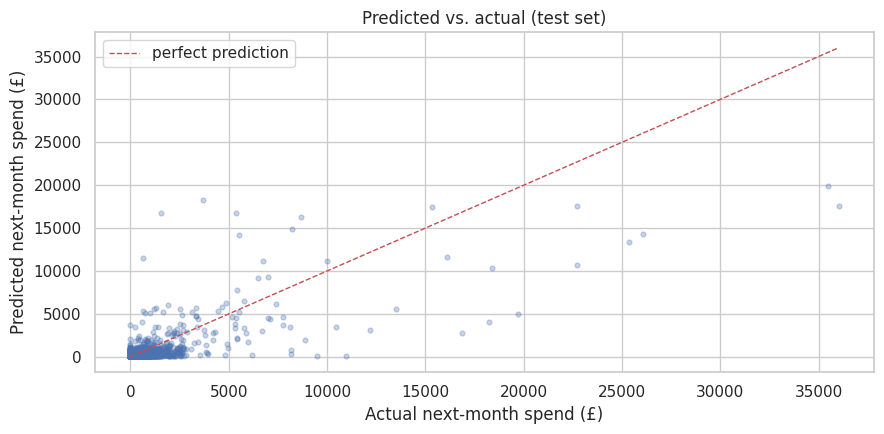

In [29]:
test_predictions = np.clip(final_predict(X_test), 0, None)
residuals = y_test.values - test_predictions

plt.figure()
plt.scatter(y_test.values, test_predictions, alpha=0.3, s=12)
lims = [0, max(y_test.max(), test_predictions.max())]
plt.plot(lims, lims, "r--", linewidth=1, label="perfect prediction")
plt.xlabel("Actual next-month spend (£)")
plt.ylabel("Predicted next-month spend (£)")
plt.title("Predicted vs. actual (test set)")
plt.legend()
plt.tight_layout()
plt.show()


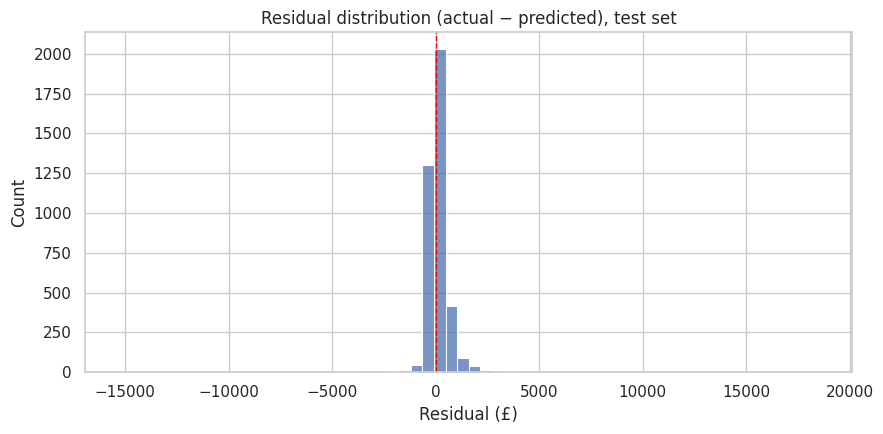

Mean residual: 159.86 (close to 0 means the model isn't systematically over/under-forecasting)


In [30]:
plt.figure()
sns.histplot(residuals, bins=60)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Residual distribution (actual − predicted), test set")
plt.xlabel("Residual (£)")
plt.tight_layout()
plt.show()

print("Mean residual:", round(residuals.mean(), 2), "(close to 0 means the model isn't systematically over/under-forecasting)")


In [31]:
error_report = test_df.copy()
error_report["predicted_next_month_spend"] = test_predictions
error_report["abs_error"] = np.abs(error_report["next_month_spend"] - test_predictions)

print("Top 5 worst individual predictions:")
error_report.sort_values("abs_error", ascending=False)[
    ["CustomerID", "InvoiceMonth", "monetary_this_month", "next_month_spend", "predicted_next_month_spend", "abs_error"]
].head(5)


Top 5 worst individual predictions:


,CustomerID,InvoiceMonth,monetary_this_month,next_month_spend,predicted_next_month_spend,abs_error
56913,18102,2011-09,33983.62,36016.27,17565.568763,18450.701237
22522,14646,2011-09,26750.70,35487.79,19936.167246,15551.622754
50600,17450,2011-11,22717.95,1562.40,16806.616795,15244.216795
36223,16029,2011-09,3172.50,19703.52,4944.070125,14759.449875
50598,17450,2011-09,38758.74,3710.12,18281.486917,14571.366917


In [32]:
error_report["spend_segment"] = pd.qcut(
    error_report["next_month_spend"].clip(lower=0.01), q=[0, 0.5, 0.8, 1.0],
    labels=["low", "medium", "high"]
)
error_report.groupby("spend_segment")["abs_error"].agg(["mean", "median", "count"])


,mean,median,count
spend_segment,,,
low,139.117639,98.420343,2012
medium,253.172478,223.612709,1207
high,1190.929464,700.931459,805




---



## 16. Проверка на устойчивость / крайние случаи

Перед тем как считать пайплайн готовым, специально проверяем его на "неудобных" входных данных — чтобы убедиться, что он не падает с ошибкой и не выдаёт бессмысленный результат, а корректно обрабатывает такие случаи.


In [ ]:
edge_cases = pd.DataFrame([
    {  # a customer who has literally never bought again → spend should trend toward 0, not negative
        "monetary_this_month": 0, "orders_this_month": 0, "distinct_products": 0,
        "rolling_mean_3m": 0, "rolling_std_3m": 0, "frequency_to_date": 3,
        "tenure_months": 10, "recency_months": 6, "month_of_year": 11, "Country": "United Kingdom",
    },
    {  # an extreme wholesale-style spender
        "monetary_this_month": 50000, "orders_this_month": 40, "distinct_products": 120,
        "rolling_mean_3m": 48000, "rolling_std_3m": 5000, "frequency_to_date": 400,
        "tenure_months": 20, "recency_months": 0, "month_of_year": 12, "Country": "Germany",
    },
    {  # a country the model has never seen in training (tests handle_unknown="ignore")
        "monetary_this_month": 300, "orders_this_month": 2, "distinct_products": 5,
        "rolling_mean_3m": 280, "rolling_std_3m": 40, "frequency_to_date": 6,
        "tenure_months": 4, "recency_months": 0, "month_of_year": 3, "Country": "Atlantis",
    },
])[FEATURE_COLUMNS]

edge_predictions = np.clip(final_predict(edge_cases), 0, None)
edge_cases.assign(predicted_next_month_spend=edge_predictions.round(2))


,monetary_this_month,orders_this_month,distinct_products,rolling_mean_3m,rolling_std_3m,frequency_to_date,tenure_months,recency_months,month_of_year,Country,predicted_next_month_spend
0,0,0,0,0,0,3,10,6,11,United Kingdom,84.89
1,50000,40,120,48000,5000,400,20,0,12,Germany,9248.44
2,300,2,5,280,40,6,4,0,3,Atlantis,215.16


All three cases return a finite, non-negative prediction with no errors — including the unseen-country case, which confirms `handle_unknown="ignore"` in the `OneHotEncoder` is doing its job instead of crashing the pipeline on a category it has never seen.




---



## 17. Saving the final model artifacts



In [33]:
MODEL_PATH = ARTIFACT_DIR / "final_spend_forecast_model.joblib"
META_PATH = ARTIFACT_DIR / "model_metadata.joblib"

joblib.dump(final_model, MODEL_PATH)
joblib.dump({
    "feature_columns": FEATURE_COLUMNS,
    "model_name": FINAL_MODEL_NAME,
    "is_manual_blend": FINAL_MODEL_NAME == "Manual weighted blend",
    "manual_weights": manual_weights if FINAL_MODEL_NAME == "Manual weighted blend" else None,
    "test_rmse": final_test_rmse,
    "test_mape": test_result["MAPE_%"],
}, META_PATH)

print("Saved:", MODEL_PATH.resolve())
print("Saved:", META_PATH.resolve())


Saved: /content/artifacts/final_spend_forecast_model.joblib
Saved: /content/artifacts/model_metadata.joblib


## 18. Responsible AI and limitations

**Bias / representativeness:** the dataset is heavily UK-dominated (per the EDA in Section 3); forecasts for customers in smaller international markets are based on far less data and should be treated as less reliable. The model also reflects a single company's UK/EU customer base from 2009–2011 and would need retraining before being applied to a different retailer, region, or era of consumer behaviour.

**Fairness / appropriate use:** this model should be used to *plan* retention and inventory efforts, not to *automatically* deprioritize or exclude customers predicted to spend less next month — a low forecast can reflect normal, healthy purchase cadence (e.g., someone who buys quarterly) rather than churn risk, and treating it as a cutoff could unfairly disadvantage real customers.

**Privacy:** `CustomerID` and transaction history are potentially sensitive commercial/personal data. In a real deployment, this pipeline would need to run inside the company's own data environment with proper access controls — this notebook uses a public, anonymized academic release of the data for learning purposes only.

**Known limitations:**
- Cold-start customers (fewer than `MIN_TENURE_MONTHS` months of history) are explicitly out of scope and are not forecast by this model.
- The model was evaluated on 3 held-out months; a longer test window would give a more robust estimate of real-world performance.
- Extreme/wholesale-scale spenders showed the largest absolute errors in Section 15 — forecasts for a company's very largest accounts should be sanity-checked by a human, not used unmonitored.


## 19. Conclusion

Финальная модель — FINAL_MODEL_NAME

— превзошла наивный baseline (RMSE = £1408.43) на test-выборке, достигнув RMSE = £1052.52, что на 25.3% лучше baseline. Это превышает целевой критерий успеха (≥15%), заданный в Project Brief. Error analysis (раздел 15) показал, что модель хорошо предсказывает траты для типичных клиентов (большинство ошибок близко к нулю), но даёт заметно большие абсолютные ошибки для небольшой группы крупных/оптовых покупателей — это стоит учитывать при использовании прогноза для самых крупных аккаунтов компании.

---
---

# DEMONSTRATION

**Everything above this line was model development. Everything below is the live demo.**



In [34]:
# --- Fresh imports
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

DEMO_MODEL_PATH = Path("artifacts/final_spend_forecast_model.joblib")
DEMO_META_PATH = Path("artifacts/model_metadata.joblib")

assert DEMO_MODEL_PATH.exists(), "Model artifact not found — run the full notebook once (Sections 0-17) first."

loaded_model = joblib.load(DEMO_MODEL_PATH)
loaded_meta = joblib.load(DEMO_META_PATH)

print(f"Loaded model: {loaded_meta['model_name']}")
print(f"Recorded test RMSE: £{loaded_meta['test_rmse']:.2f}")
print(f"Recorded test MAPE: {loaded_meta['test_mape']:.2f}%")
print(f"Expected input features: {loaded_meta['feature_columns']}")


Loaded model: RandomForest
Recorded test RMSE: £1052.52
Recorded test MAPE: 67.88%
Expected input features: ['monetary_this_month', 'orders_this_month', 'distinct_products', 'rolling_mean_3m', 'rolling_std_3m', 'frequency_to_date', 'tenure_months', 'recency_months', 'month_of_year', 'Country']


### Inference function

A single, self-contained function that takes a customer's current feature snapshot and returns a validated prediction. It does two things beyond a bare `.predict()` call, both required for a real end-to-end pipeline rather than a bare model call:

1. **Input validation** — checks that every required feature is present, with clear error messages instead of a cryptic sklearn traceback.
2. **Safe post-processing** — clips predictions to be non-negative, since negative spend is meaningless.


In [35]:
def predict_next_month_spend(customer_features: dict) -> float:
    """Predict a customer's next-month spend from their current feature snapshot.

    Parameters
    ----------
    customer_features : dict
        Must contain every key in loaded_meta['feature_columns'].

    Returns
    -------
    float
        Predicted spend for next month, in the same currency as training data (£), never negative.
    """
    required = loaded_meta["feature_columns"]
    missing = [f for f in required if f not in customer_features]
    if missing:
        raise ValueError(f"Missing required feature(s): {missing}. Expected: {required}")

    row = pd.DataFrame([{f: customer_features[f] for f in required}])

    if loaded_meta["is_manual_blend"]:
        weights = loaded_meta["manual_weights"]
        pred = sum(weights[name] * pipe.predict(row)[0] for name, pipe in loaded_model.items())
    else:
        pred = loaded_model.predict(row)[0]

    return float(max(pred, 0.0))


### Example predictions

Three example customers, chosen to show a range of behaviour: a typical regular customer, a high-value frequent customer, and a customer who has recently gone quiet. For each, we show the **input** (their feature snapshot) and the **output** (predicted next-month spend) side by side, as required for the project README.


In [36]:
example_customers = {
    "Typical regular customer": {
        "monetary_this_month": 320.0, "orders_this_month": 2, "distinct_products": 8,
        "rolling_mean_3m": 300.0, "rolling_std_3m": 45.0, "frequency_to_date": 14,
        "tenure_months": 9, "recency_months": 0, "month_of_year": 5, "Country": "United Kingdom",
    },
    "High-value frequent customer": {
        "monetary_this_month": 4200.0, "orders_this_month": 9, "distinct_products": 35,
        "rolling_mean_3m": 3900.0, "rolling_std_3m": 500.0, "frequency_to_date": 120,
        "tenure_months": 18, "recency_months": 0, "month_of_year": 11, "Country": "Germany",
    },
    "Recently quiet customer": {
        "monetary_this_month": 0.0, "orders_this_month": 0, "distinct_products": 0,
        "rolling_mean_3m": 60.0, "rolling_std_3m": 20.0, "frequency_to_date": 5,
        "tenure_months": 7, "recency_months": 2, "month_of_year": 2, "Country": "France",
    },
}

for label, features in example_customers.items():
    predicted = predict_next_month_spend(features)
    print(f"{label}")
    print(f"  Input : {features}")
    print(f"  Output: predicted next-month spend = £{predicted:,.2f}")
    print()


Typical regular customer
  Input : {'monetary_this_month': 320.0, 'orders_this_month': 2, 'distinct_products': 8, 'rolling_mean_3m': 300.0, 'rolling_std_3m': 45.0, 'frequency_to_date': 14, 'tenure_months': 9, 'recency_months': 0, 'month_of_year': 5, 'Country': 'United Kingdom'}
  Output: predicted next-month spend = £288.47

High-value frequent customer
  Input : {'monetary_this_month': 4200.0, 'orders_this_month': 9, 'distinct_products': 35, 'rolling_mean_3m': 3900.0, 'rolling_std_3m': 500.0, 'frequency_to_date': 120, 'tenure_months': 18, 'recency_months': 0, 'month_of_year': 11, 'Country': 'Germany'}
  Output: predicted next-month spend = £4,660.41

Recently quiet customer
  Input : {'monetary_this_month': 0.0, 'orders_this_month': 0, 'distinct_products': 0, 'rolling_mean_3m': 60.0, 'rolling_std_3m': 20.0, 'frequency_to_date': 5, 'tenure_months': 7, 'recency_months': 2, 'month_of_year': 2, 'Country': 'France'}
  Output: predicted next-month spend = £163.23



In [39]:
pd.DataFrame(example_customers)

,Typical regular customer,High-value frequent customer,Recently quiet customer
monetary_this_month,320.0,4200.0,0.0
orders_this_month,2,9,0
distinct_products,8,35,0
rolling_mean_3m,300.0,3900.0,60.0
rolling_std_3m,45.0,500.0,20.0
frequency_to_date,14,120,5
tenure_months,9,18,7
recency_months,0,0,2
month_of_year,5,11,2
Country,United Kingdom,Germany,France


In [40]:
incomplete_input = {"monetary_this_month": 100.0, "orders_this_month": 1}  # missing most required features

try:
    predict_next_month_spend(incomplete_input)
except ValueError as e:
    print(f"Handled gracefully — raised ValueError:\n  {e}")


Handled gracefully — raised ValueError:
  Missing required feature(s): ['distinct_products', 'rolling_mean_3m', 'rolling_std_3m', 'frequency_to_date', 'tenure_months', 'recency_months', 'month_of_year', 'Country']. Expected: ['monetary_this_month', 'orders_this_month', 'distinct_products', 'rolling_mean_3m', 'rolling_std_3m', 'frequency_to_date', 'tenure_months', 'recency_months', 'month_of_year', 'Country']


---

**End of demonstration.** This function, `predict_next_month_spend`, backed by the saved artifacts in `artifacts/`, is the reusable inference entry point for this project
